In [228]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import classification_report, f1_score

from lightgbm import LGBMClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain

In [229]:
df = pd.read_csv("ClaimDenialInputMultiLabel.csv")

C:\Users\SreejaChiluveru\AppData\Local\Temp\ipykernel_3744\3972365444.py:1: DtypeWarning: Columns (18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("ClaimDenialInputMultiLabel.csv")


In [230]:
df.shape
df.info()
df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 39 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   Clinic                   1000000 non-null  object 
 1   TPCLIID                  1000000 non-null  object 
 2   LIATPCLIid               926015 non-null   object 
 3   ServiceDt                1000000 non-null  object 
 4   Service                  1000000 non-null  object 
 5   ClaimID                  1000000 non-null  int64  
 6   AmountCharged            1000000 non-null  float64
 7   CPTCode                  1000000 non-null  object 
 8   ClientID                 1000000 non-null  object 
 9   ClaimBillDate            1000000 non-null  object 
 10  Payer                    1000000 non-null  object 
 11  Provider                 999988 non-null   object 
 12  BillingProviderNPI       1000000 non-null  object 
 13  ClaimFacilityNPI         1000000 non-null  

,Clinic,TPCLIID,LIATPCLIid,ServiceDt,Service,ClaimID,AmountCharged,CPTCode,ClientID,ClaimBillDate,...,CoIns,CltResp,Balance,MultiFlag,SameDayCli,DaysBetServiceToBilling,tpcliStrModifier,tpcliStrPOS,f21diag1,f11insdob
0,CLN_13838227,TP_41935074,LTP_1870199,2025-06-22,Methadone Maintenance Week,143008644,297.61,H0020,CLT_85822412,2025-04-06,...,0.0,0.0,0.00,N,0,1,NaN,11,F1120,NaN
1,CLN_13838227,TP_44604858,LTP_82010373,2025-06-29,Methadone Maintenance Week,143008720,208.74,H0020,CLT_85822412,2025-04-13,...,0.0,0.0,0.00,N,0,1,NaN,11,F1120,NaN
2,CLN_13838227,TP_26594858,NaN,2025-07-06,Methadone Maintenance Week,143009390,238.49,H0020,CLT_85822412,2025-06-03,...,0.0,0.0,224.01,NaN,0,45,NaN,11,F1120,NaN
3,CLN_13838227,TP_95683641,LTP_2144057,2025-07-13,Methadone Maintenance Week,143008875,245.26,H0020,CLT_85822412,2025-04-27,...,0.0,0.0,283.10,Z,0,1,NaN,11,F1120,NaN
4,CLN_13838227,TP_90042682,LTP_38875939,2025-07-20,Methadone Maintenance Week,143008961,228.32,H0020,CLT_85822412,2025-05-05,...,0.0,0.0,226.06,Z,0,2,NaN,11,F1120,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,CLN_20041488,TP_28231781,LTP_22240665,2025-10-19,Take Home Dose MMT,105186924,6.70,H0020,CLT_82150984,2025-04-27,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN
999996,CLN_20041488,TP_14603567,LTP_86430893,2025-10-25,Take Home Dose MMT,105187299,8.68,H0020,CLT_82150984,2025-05-04,...,0.0,0.0,0.00,N,0,3,NaN,11,F1120,NaN
999997,CLN_20041488,TP_67501817,LTP_63741515,2025-10-26,Take Home Dose MMT,105187299,7.39,H0020,CLT_82150984,2025-05-04,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN
999998,CLN_20041488,TP_83554380,LTP_50442122,2025-11-02,Take Home Dose MMT,105187791,8.79,H0020,CLT_82150984,2025-05-11,...,0.0,0.0,0.00,N,0,2,NaN,11,F1120,NaN


using sample data for eda  and creating delay

In [231]:
df_sample = df.sample(100000, random_state=42)

fixing dates

In [232]:
df_sample['ServiceDt'] = pd.to_datetime(df_sample['ServiceDt'])
df_sample['ClaimBillDate'] = pd.to_datetime(df_sample['ClaimBillDate'])

df_sample['delay'] = (df_sample['ClaimBillDate'] - df_sample['ServiceDt']).dt.days

# remove invalid
df_sample = df_sample[df_sample['delay'] >= 0]

target eda


In [233]:
targets = ['target1', 'target2', 'target3', 'target4']

df_sample['labels'] = df_sample[targets].values.tolist()
df_sample['labels'] = df_sample['labels'].apply(lambda x: [i for i in x if pd.notna(i)])

In [234]:
all_labels = pd.Series([l for sub in df_sample['labels'] for l in sub])
label_counts = all_labels.value_counts()

label_counts.head(20)

23.0    400
8.0     282
32.0    235
14.0    196
5.0     155
31.0    119
2.0      77
25.0     50
3.0      48
21.0     41
19.0     34
16.0     32
11.0     26
15.0     23
22.0     19
9.0      14
10.0     13
13.0     11
17.0      6
7.0       2
Name: count, dtype: int64

ACTION REQUIRED FOR TTHIS ONE

In [235]:
min_support = 30

valid_labels = label_counts[label_counts >= min_support].index

df_sample['labels'] = df_sample['labels'].apply(
    lambda x: [i for i in x if i in valid_labels]
)

In [236]:
df_sample['label_count'] = df_sample['labels'].apply(len)

df_sample['label_count'].value_counts()

label_count
0    2969
1    1228
2     184
3      23
4       1
Name: count, dtype: int64

3072 rows have 0 labels

This means:

After pruning → labels became empty
These rows are now useless for training

THIS WILL BREAK YOUR MODEL

If you continue like this:

Model learns from incomplete data 
Metrics become misleading 
Underfitting risk 
 FIX (MANDATORY):::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::: 

Step 1: REMOVE empty label rows

In [237]:
df_sample = df_sample[df_sample['label_count'] > 0]

recheck distribution

In [238]:
df_sample['label_count'].value_counts()

label_count
1    1228
2     184
3      23
4       1
Name: count, dtype: int64

In [239]:
len(label_counts)

20

In [240]:
(label_counts < 50).sum()

np.int64(12)

check label relationships


In [241]:
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np

mlb = MultiLabelBinarizer()
Y_temp = mlb.fit_transform(df_sample['labels'])

co_matrix = np.dot(Y_temp.T, Y_temp)

co_matrix

array([[ 77,   0,  49,   1,   1,   0,   4,   0,   2,   0,   0,   0],
       [  0,  48,   0,   2,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 49,   0, 155,   0,   6,   0,   0,   1,   9,   1,   0,  15],
       [  1,   2,   0, 282,   2,   1,   9,   3,  21,   0,  12,   0],
       [  1,   0,   6,   2, 196,   1,   8,   0,   3,   0,   2,  22],
       [  0,   0,   0,   1,   1,  32,   1,   0,   0,   0,   1,   0],
       [  4,   0,   0,   9,   8,   1,  34,   0,   3,   0,   6,   8],
       [  0,   0,   1,   3,   0,   0,   0,  41,  22,   1,   1,   0],
       [  2,   0,   9,  21,   3,   0,   3,  22, 400,   0,  26,  15],
       [  0,   0,   1,   0,   0,   0,   0,   1,   0,  50,   0,   0],
       [  0,   0,   0,  12,   2,   1,   6,   1,  26,   0, 119,   0],
       [  0,   0,  15,   0,  22,   0,   8,   0,  15,   0,   0, 235]])

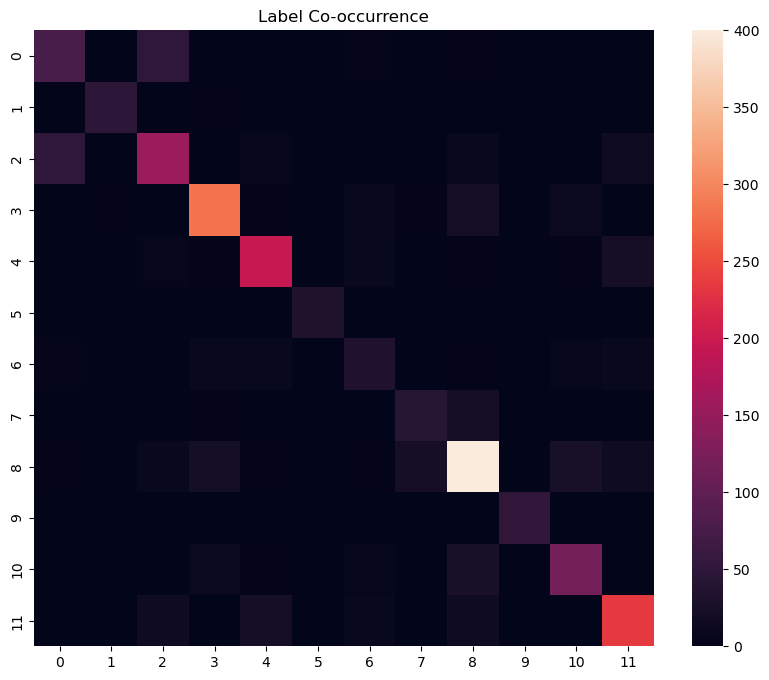

In [242]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(co_matrix)
plt.title("Label Co-occurrence")
plt.show()

insight :Labels are NOT independent

Even though:

Most rows = 1 label
Some labels frequently appear together



MODEL CHOICE::
Classifier Chains (MANDATORY)

------------------------------------------------------------------------------------------------------------------------------------

FEATURE vs LABEL ANALYSIS (CRITICAL)

1 CPTCode vs label_count (VERY IMPORTANT)::CPT codes are strong drivers of denial reasons

In [243]:
df_sample.groupby('CPTCode')['label_count'].mean().sort_values(ascending=False).head(10)

CPTCode
G2087    1.772727
99205    1.500000
G2074    1.406780
G2068    1.400000
80305    1.369369
H0004    1.333333
G2079    1.333333
82075    1.250000
99214    1.222222
G2078    1.177778
Name: label_count, dtype: float64

INSIGHT:Certain CPT codes consistently produce more denial reasons

 This is one of your strongest features

2.PAYER VS LABEL COUNT 
Why:
Some payers reject more / differently2.

In [244]:
df_sample.groupby('Payer')['label_count'].mean().sort_values(ascending=False).head(10)

Payer
PAY_90206459    3.00
PAY_43328415    2.75
PAY_40056146    2.50
PAY_22935793    2.00
PAY_46929234    2.00
PAY_41347409    2.00
PAY_55963010    2.00
PAY_23572537    2.00
PAY_34850980    2.00
PAY_1638498     2.00
Name: label_count, dtype: float64

3. Provider vs label_count

In [245]:
df_sample.groupby('Provider')['label_count'].mean().sort_values(ascending=False).head(10)

Provider
PRV_25149571    2.000000
PRV_43934556    1.600000
PRV_11649801    1.533333
PRV_94659224    1.500000
PRV_27952515    1.500000
PRV_42211394    1.500000
PRV_15063426    1.500000
PRV_97250224    1.400000
PRV_40618137    1.400000
PRV_70280155    1.375000
Name: label_count, dtype: float64


4. AmountCharged vs label_count

In [246]:
df_sample.groupby('label_count')['AmountCharged'].mean()

label_count
1     78.266490
2     82.963913
3    130.676957
4    192.560000
Name: AmountCharged, dtype: float64

INSIGHT:Higher amount → more denial reasons

5.Delay vs label_count |

In [247]:
df_sample.groupby('label_count')['DaysBetServiceToBilling'].mean()

label_count
1    117.433225
2    143.581522
3    108.130435
4     62.000000
Name: DaysBetServiceToBilling, dtype: float64

6. SameDayCli vs label_count

In [248]:
df_sample.groupby('SameDayCli')['label_count'].mean()

SameDayCli
0    1.152396
1    1.243750
2    1.000000
3    1.000000
Name: label_count, dtype: float64

<Axes: >

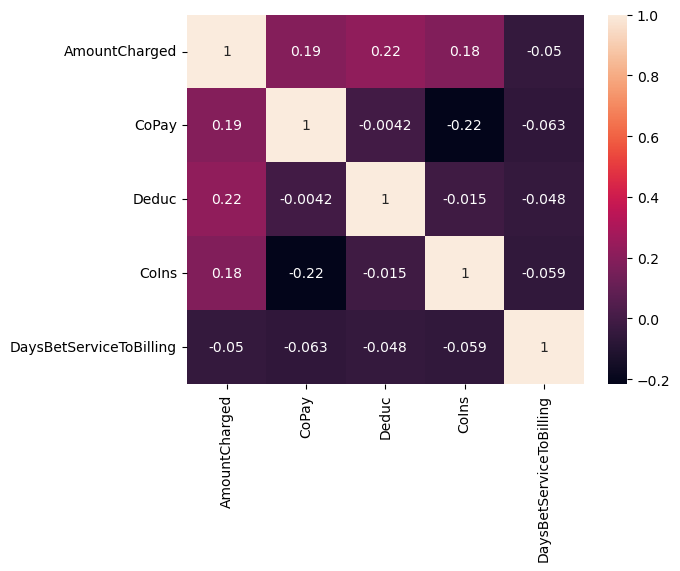

In [249]:
import seaborn as sns

num_cols = ['AmountCharged','CoPay','Deduc','CoIns','DaysBetServiceToBilling']
sns.heatmap(df_sample[num_cols].corr(), annot=True)

CHECKING MISSING VALUES

In [250]:
df_sample.isnull().mean().sort_values(ascending=False).head(10)

AuthStatus          1.000000
f11insdob           1.000000
target4             0.999304
target3             0.977716
cliANSI2            0.947075
target2             0.833565
tpcliStrModifier    0.495125
eligStatus          0.328691
tpcliStrPOS         0.000000
TotalPaid           0.000000
dtype: float64

In [251]:
df_raw=df.copy()

FIXES FOR ABOVE EDA

creating labels

In [252]:
targets = ['target1', 'target2', 'target3', 'target4']

df['labels'] = df[targets].values.tolist()
df['labels'] = df['labels'].apply(lambda x: [i for i in x if pd.notna(i)])

applying same pruning

In [253]:
all_labels = pd.Series([l for sub in df['labels'] for l in sub])
label_counts = all_labels.value_counts()

min_support = 30

valid_labels = label_counts[label_counts >= min_support].index

df['labels'] = df['labels'].apply(
    lambda x: [i for i in x if i in valid_labels]
)

creating label_count

In [254]:
df['label_count'] = df['labels'].apply(len)

remove empty rows

In [255]:
df = df[df['label_count'] > 0].copy()

fix for cpt rate

In [256]:
cpt_rate = df.groupby('CPTCode')['label_count'].mean()
df.loc[:, 'cpt_denial_rate'] = df['CPTCode'].map(cpt_rate)

In [257]:
df.columns

Index(['Clinic', 'TPCLIID', 'LIATPCLIid', 'ServiceDt', 'Service', 'ClaimID',
       'AmountCharged', 'CPTCode', 'ClientID', 'ClaimBillDate', 'Payer',
       'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'AuthStatus',
       'eligStatus', 'DenialFlag', 'lastActDt', 'cliANSI1', 'cliANSI2',
       'target1', 'target2', 'target3', 'target4', 'TotalPaid', 'TotalAdj',
       'TotalVoid', 'CoPay', 'Deduc', 'CoIns', 'CltResp', 'Balance',
       'MultiFlag', 'SameDayCli', 'DaysBetServiceToBilling',
       'tpcliStrModifier', 'tpcliStrPOS', 'f21diag1', 'f11insdob', 'labels',
       'label_count', 'cpt_denial_rate'],
      dtype='object')

FIX ACTION FOR PAYER VS LABEL_COUNT

In [258]:
payer_rate = df.groupby('Payer')['label_count'].mean()
df.loc[:, 'payer_denial_rate'] = df['Payer'].map(payer_rate)

In [259]:
print('labels' in df.columns)
print('label_count' in df.columns)

True
True


In [260]:
df = df.drop_duplicates(subset=[col for col in df.columns if col != 'labels'])

In [261]:
df = df.drop_duplicates(subset=[
    'ClientID', 'CPTCode', 'ServiceDt'
]).copy()

DROPPING THE COLUMNS

In [262]:
drop_cols = [
    'AuthStatus', 'cliANSI2',
    'Balance', 'CltResp', 'MultiFlag', 'DenialFlag'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

In [263]:
df.columns

Index(['Clinic', 'TPCLIID', 'LIATPCLIid', 'ServiceDt', 'Service', 'ClaimID',
       'AmountCharged', 'CPTCode', 'ClientID', 'ClaimBillDate', 'Payer',
       'Provider', 'BillingProviderNPI', 'ClaimFacilityNPI', 'eligStatus',
       'lastActDt', 'cliANSI1', 'target1', 'target2', 'target3', 'target4',
       'TotalPaid', 'TotalAdj', 'TotalVoid', 'CoPay', 'Deduc', 'CoIns',
       'SameDayCli', 'DaysBetServiceToBilling', 'tpcliStrModifier',
       'tpcliStrPOS', 'f21diag1', 'f11insdob', 'labels', 'label_count',
       'cpt_denial_rate', 'payer_denial_rate'],
      dtype='object')

In [264]:
df.isnull().sum()

Clinic                          0
TPCLIID                         0
LIATPCLIid                      0
ServiceDt                       0
Service                         0
ClaimID                         0
AmountCharged                   0
CPTCode                         0
ClientID                        0
ClaimBillDate                   0
Payer                           0
Provider                        0
BillingProviderNPI              0
ClaimFacilityNPI                0
eligStatus                  55559
lastActDt                       0
cliANSI1                        0
target1                         0
target2                    179298
target3                    208241
target4                    211101
TotalPaid                       0
TotalAdj                        0
TotalVoid                       0
CoPay                           0
Deduc                           0
CoIns                           0
SameDayCli                      0
DaysBetServiceToBilling         0
tpcliStrModifi

dropping target columns

In [265]:
targets = ['target1', 'target2', 'target3', 'target4']

df = df.drop(columns=targets)

removing lekage features

In [266]:
df = df.drop(columns=['TotalPaid', 'TotalAdj', 'TotalVoid'])

In [267]:
df = df.drop(columns=['cliANSI1'])

removing extra id based columns

In [268]:
df = df.drop(columns=['TPCLIID', 'LIATPCLIid', 'ClaimID'])

In [269]:
df = df.drop(columns=['f11insdob'])

fixing nulla

In [270]:
df['eligStatus'] = df['eligStatus'].fillna('unknown')

In [271]:
df.loc[:, 'tpcliStrModifier'] = df['tpcliStrModifier'].fillna('missing')

raw datas are not useful so converting them 

In [272]:
df['ServiceDt'] = pd.to_datetime(df['ServiceDt'])
df['ClaimBillDate'] = pd.to_datetime(df['ClaimBillDate'])

df['service_month'] = df['ServiceDt'].dt.month
df['service_day'] = df['ServiceDt'].dt.day

In [273]:
df.columns

Index(['Clinic', 'ServiceDt', 'Service', 'AmountCharged', 'CPTCode',
       'ClientID', 'ClaimBillDate', 'Payer', 'Provider', 'BillingProviderNPI',
       'ClaimFacilityNPI', 'eligStatus', 'lastActDt', 'CoPay', 'Deduc',
       'CoIns', 'SameDayCli', 'DaysBetServiceToBilling', 'tpcliStrModifier',
       'tpcliStrPOS', 'f21diag1', 'labels', 'label_count', 'cpt_denial_rate',
       'payer_denial_rate', 'service_month', 'service_day'],
      dtype='object')

In [274]:
df.isnull().sum()

Clinic                     0
ServiceDt                  0
Service                    0
AmountCharged              0
CPTCode                    0
ClientID                   0
ClaimBillDate              0
Payer                      0
Provider                   0
BillingProviderNPI         0
ClaimFacilityNPI           0
eligStatus                 0
lastActDt                  0
CoPay                      0
Deduc                      0
CoIns                      0
SameDayCli                 0
DaysBetServiceToBilling    0
tpcliStrModifier           0
tpcliStrPOS                0
f21diag1                   0
labels                     0
label_count                0
cpt_denial_rate            0
payer_denial_rate          0
service_month              0
service_day                0
dtype: int64

In [275]:
df_raw=df.copy()

In [276]:
print('labels' in df_raw.columns)       # should be True
print('ClientID' in df_raw.columns)     # needed for GroupSplit

True
True


SAVING DF_G FOR GROUP SPLIT

In [300]:
df_g=df_raw.copy()

CREATING X AND Y FEATURES


In [301]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df_g['labels'])

X = df_g.drop(columns=['labels'])

DOING GROUP SPLIT

In [302]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss.split(X, Y, groups=df_g['ClientID']))

X_train = X.iloc[train_idx].copy()
X_val   = X.iloc[val_idx].copy()

Y_train = Y[train_idx]
Y_val   = Y[val_idx]

FREQ ENCOINDG ONLY ON TRAIN

In [303]:
high_card_cols = [
    'Clinic','ClientID','Payer','Provider',
    'BillingProviderNPI','ClaimFacilityNPI','CPTCode'
]

for col in high_card_cols:
    freq = X_train[col].value_counts()
    
    X_train[col + '_freq'] = X_train[col].map(freq)
    X_val[col + '_freq']   = X_val[col].map(freq)
    
    # handle unseen categories
    X_val[col + '_freq'] = X_val[col + '_freq'].fillna(0)

HANDLING UNSEEN CATEGORIES

In [304]:
for col in high_card_cols:
    X_val[col + '_freq'] = X_val[col + '_freq'].fillna(0)

DROPPING ORIGINAL HIGH HARD COLUMNS

In [305]:
X_train = X_train.drop(columns=high_card_cols)
X_val   = X_val.drop(columns=high_card_cols)

STEP 5: Low-card encoding (SAFE)
Fit on train, apply to val:

In [306]:
cat_cols = [
    'Service','eligStatus','tpcliStrModifier',
    'tpcliStrPOS','f21diag1'
]

X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_val   = pd.get_dummies(X_val, columns=cat_cols, drop_first=True)

ALIGN COLUMNS

In [307]:
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

NUMERIC TRANSFORMATION

In [308]:
import numpy as np

X_train['log_amount'] = np.log1p(X_train['AmountCharged'])
X_val['log_amount']   = np.log1p(X_val['AmountCharged'])

X_train = X_train.drop(columns=['AmountCharged'])
X_val   = X_val.drop(columns=['AmountCharged'])

In [309]:
date_cols = X_train.select_dtypes(include=['datetime64']).columns

X_train = X_train.drop(columns=date_cols)
X_val   = X_val.drop(columns=date_cols)

In [310]:
# 🔥 STEP 10: Final safety (optional but recommended)
X_train = X_train.drop(columns=X_train.select_dtypes(include='object').columns)
X_val   = X_val.drop(columns=X_val.select_dtypes(include='object').columns)

In [311]:
print(X_train.shape, X_val.shape)
print(Y_train.shape, Y_val.shape)

(169792, 162) (42294, 162)
(169792, 24) (42294, 24)


In [312]:
print(len(mlb.classes_))
print(mlb.classes_)

24
[2.0 3.0 4.0 5.0 7.0 8.0 9.0 10.0 11.0 13.0 14.0 15.0 16.0 17.0 19.0 20.0
 21.0 22.0 23.0 24.0 25.0 31.0 32.0 999.0]


In [313]:
cols_to_drop = ['TPCLIID', 'LIATPCLIid', 'lastActDt']

X_train = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_val   = X_val.drop(columns=[c for c in cols_to_drop if c in X_val.columns])

In [ ]:
# df_g=df_raw.copy()

In [314]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

LIGHTGBM MODEL TRAINING

In [315]:
from lightgbm import LGBMClassifier
from sklearn.multioutput import ClassifierChain
import numpy as np

In [316]:
base_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

Classifier Chain (use label frequency order)

In [317]:
order = np.argsort(-Y_train.sum(axis=0))

model = ClassifierChain(base_model, order=order)

model.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 59079, number of negative: 110713
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009813 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2279
[LightGBM] [Info] Number of data points in the train set: 169792, number of used features: 125
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347949 -> initscore=-0.628066
[LightGBM] [Info] Start training from score -0.628066
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,estimator,LGBMClassifie...subsample=0.8)
,order,"array([18, 5..., 13, 2, 23])"
,cv,None
,chain_method,'predict'
,random_state,None
,verbose,False
,base_estimator,'deprecated'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.05


In [322]:
probs = model.predict_proba(X_val)

# convert list → array
probs = model.predict_proba(X_val)

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

In [323]:
Y_pred = (probs > 0.3).astype(int)

In [324]:
from sklearn.metrics import f1_score

print("Micro F1:", f1_score(Y_val, Y_pred, average='micro'))
print("Macro F1:", f1_score(Y_val, Y_pred, average='macro'))

Micro F1: 0.87228391852937
Macro F1: 0.6077106258854732


In [328]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("===== VALIDATION METRICS =====")

print("Micro Precision:", precision_score(Y_val, Y_pred_opt, average='micro'))
print("Micro Recall   :", recall_score(Y_val, Y_pred_opt, average='micro'))
print("Micro F1       :", f1_score(Y_val, Y_pred_opt, average='micro'))

print("\nMacro Precision:", precision_score(Y_val, Y_pred_opt, average='macro'))
print("Macro Recall   :", recall_score(Y_val, Y_pred_opt, average='macro'))
print("Macro F1       :", f1_score(Y_val, Y_pred_opt, average='macro'))

print("\nSamples F1:", f1_score(Y_val, Y_pred_opt, average='samples'))

===== VALIDATION METRICS =====
Micro Precision: 0.8698863528202395
Micro Recall   : 0.9106598377807449
Micro F1       : 0.8898062506085094

Macro Precision: 0.626548116800904
Macro Recall   : 0.6924084874472493
Macro F1       : 0.6408023837046399

Samples F1: 0.8880542551346922


In [329]:
from sklearn.metrics import classification_report

print(classification_report(Y_val, Y_pred_opt))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2121
           1       0.30      0.83      0.44       239
           2       0.00      0.35      0.01        17
           3       0.84      0.79      0.82      2339
           4       0.50      0.77      0.60        74
           5       0.97      0.95      0.96     13019
           6       0.70      0.86      0.77      1149
           7       0.41      0.25      0.31       206
           8       0.90      0.83      0.86      1242
           9       0.59      0.66      0.63       152
          10       0.75      0.82      0.78      2087
          11       0.60      0.59      0.60      1204
          12       0.34      0.64      0.44       196
          13       0.42      0.67      0.51        15
          14       0.94      0.91      0.93      1816
          15       0.00      0.00      0.00        18
          16       0.78      0.65      0.71       717
          17       0.97    

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


TRYHING WITH DIFFERNT THRESHOLDS

In [325]:
from sklearn.metrics import f1_score
import numpy as np

thresholds = []

for i in range(Y_val.shape[1]):
    best_f1 = 0
    best_t = 0.3
    
    for t in np.arange(0.1, 0.6, 0.05):
        pred = (probs[:, i] > t).astype(int)
        f1 = f1_score(Y_val[:, i], pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    thresholds.append(best_t)

In [326]:
Y_pred_opt = np.zeros_like(Y_val)

for i in range(len(thresholds)):
    Y_pred_opt[:, i] = (probs[:, i] > thresholds[i]).astype(int)

In [327]:
print("Micro F1:", f1_score(Y_val, Y_pred_opt, average='micro'))
print("Macro F1:", f1_score(Y_val, Y_pred_opt, average='macro'))

Micro F1: 0.8898062506085094
Macro F1: 0.6408023837046399


In [330]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("===== VALIDATION METRICS =====")

print("Micro Precision:", precision_score(Y_val, Y_pred_opt, average='micro'))
print("Micro Recall   :", recall_score(Y_val, Y_pred_opt, average='micro'))
print("Micro F1       :", f1_score(Y_val, Y_pred_opt, average='micro'))

print("\nMacro Precision:", precision_score(Y_val, Y_pred_opt, average='macro'))
print("Macro Recall   :", recall_score(Y_val, Y_pred_opt, average='macro'))
print("Macro F1       :", f1_score(Y_val, Y_pred_opt, average='macro'))

print("\nSamples F1:", f1_score(Y_val, Y_pred_opt, average='samples'))

===== VALIDATION METRICS =====
Micro Precision: 0.8698863528202395
Micro Recall   : 0.9106598377807449
Micro F1       : 0.8898062506085094

Macro Precision: 0.626548116800904
Macro Recall   : 0.6924084874472493
Macro F1       : 0.6408023837046399

Samples F1: 0.8880542551346922


In [331]:
from sklearn.metrics import classification_report

print(classification_report(Y_val, Y_pred_opt))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      2121
           1       0.30      0.83      0.44       239
           2       0.00      0.35      0.01        17
           3       0.84      0.79      0.82      2339
           4       0.50      0.77      0.60        74
           5       0.97      0.95      0.96     13019
           6       0.70      0.86      0.77      1149
           7       0.41      0.25      0.31       206
           8       0.90      0.83      0.86      1242
           9       0.59      0.66      0.63       152
          10       0.75      0.82      0.78      2087
          11       0.60      0.59      0.60      1204
          12       0.34      0.64      0.44       196
          13       0.42      0.67      0.51        15
          14       0.94      0.91      0.93      1816
          15       0.00      0.00      0.00        18
          16       0.78      0.65      0.71       717
          17       0.97    

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [334]:
train_probs = model.predict_proba(X_train)
train_pred = (train_probs > 0.3).astype(int)

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

In [335]:
train_pred_opt = np.zeros_like(Y_train)

for i in range(len(thresholds)):
    train_pred_opt[:, i] = (train_probs[:, i] > thresholds[i]).astype(int)

In [336]:
print("Train Micro F1:", f1_score(Y_train, train_pred_opt, average='micro'))
print("Val   Micro F1:", f1_score(Y_val, Y_pred_opt, average='micro'))

print("Train Macro F1:", f1_score(Y_train, train_pred_opt, average='macro'))
print("Val   Macro F1:", f1_score(Y_val, Y_pred_opt, average='macro'))

Train Micro F1: 0.9560059910134798
Val   Micro F1: 0.8898062506085094
Train Macro F1: 0.8794534300610897
Val   Macro F1: 0.6408023837046399


In [337]:
from lightgbm import LGBMClassifier

base_model_new = LGBMClassifier(
    n_estimators=120,        # ↓ reduces overfitting
    learning_rate=0.05,      # slower learning = better generalization
    max_depth=5,             # limits tree complexity
    num_leaves=25,           # controls splits
    min_child_samples=50,    # prevents learning noise
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    reg_alpha=0.1,           # L1 regularization
    reg_lambda=1.0,          # L2 regularization
    random_state=42
)

In [338]:
order = np.argsort(-Y_train.sum(axis=0))

model = ClassifierChain(base_model_new, order=order)

model.fit(X_train, Y_train)

[LightGBM] [Info] Number of positive: 59079, number of negative: 110713
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006390 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2237
[LightGBM] [Info] Number of data points in the train set: 169792, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347949 -> initscore=-0.628066
[LightGBM] [Info] Start training from score -0.628066
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

,estimator,LGBMClassifie...subsample=0.8)
,order,"array([18, 5..., 13, 2, 23])"
,cv,None
,chain_method,'predict'
,random_state,None
,verbose,False
,base_estimator,'deprecated'
,boosting_type,'gbdt'
,num_leaves,25
,max_depth,5
,learning_rate,0.05


In [339]:
probs = model.predict_proba(X_val)

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  

In [343]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = []

for i in range(Y_val.shape[1]):
    best_f1 = 0
    best_t = 0.3
    
    for t in np.arange(0.1, 0.6, 0.05):
        pred = (probs[:, i] > t).astype(int)
        f1 = f1_score(Y_val[:, i], pred)
        
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    
    thresholds.append(float(best_t))  # also fix dtype here

In [346]:
print(len(thresholds))
print(thresholds)

24
[0.40000000000000013, 0.5000000000000001, 0.45000000000000007, 0.3500000000000001, 0.20000000000000004, 0.45000000000000007, 0.45000000000000007, 0.5500000000000002, 0.20000000000000004, 0.40000000000000013, 0.5500000000000002, 0.40000000000000013, 0.5000000000000001, 0.30000000000000004, 0.1, 0.3, 0.40000000000000013, 0.25000000000000006, 0.3500000000000001, 0.25000000000000006, 0.30000000000000004, 0.45000000000000007, 0.5500000000000002, 0.3]


In [345]:
Y_pred_opt = np.zeros_like(Y_val)

for i in range(len(thresholds)):
    Y_pred_opt[:, i] = (probs[:, i] > thresholds[i]).astype(int)

In [347]:
from sklearn.metrics import f1_score

print("FINAL RESULTS")
print("Micro F1:", f1_score(Y_val, Y_pred_opt, average='micro'))
print("Macro F1:", f1_score(Y_val, Y_pred_opt, average='macro'))

FINAL RESULTS
Micro F1: 0.8948200280320878
Macro F1: 0.6564174014333042


In [348]:
train_probs = model.predict_proba(X_train)

train_pred_opt = np.zeros_like(Y_train)

for i in range(len(thresholds)):
    train_pred_opt[:, i] = (train_probs[:, i] > thresholds[i]).astype(int)

print("\nOVERFITTING CHECK")
print("Train Micro F1:", f1_score(Y_train, train_pred_opt, average='micro'))
print("Val   Micro F1:", f1_score(Y_val, Y_pred_opt, average='micro'))

print("Train Macro F1:", f1_score(Y_train, train_pred_opt, average='macro'))
print("Val   Macro F1:", f1_score(Y_val, Y_pred_opt, average='macro'))

c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\SreejaChiluveru\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  


OVERFITTING CHECK
Train Micro F1: 0.9141813816468556
Val   Micro F1: 0.8948200280320878
Train Macro F1: 0.7889326371406594
Val   Macro F1: 0.6564174014333042


In [350]:
total = len(X_train) + len(X_val)

print("Total samples:", total)
print("Train samples:", len(X_train), "(", round(len(X_train)/total*100, 2), "% )")
print("Val samples:", len(X_val), "(", round(len(X_val)/total*100, 2), "% )")

Total samples: 212086
Train samples: 169792 ( 80.06 % )
Val samples: 42294 ( 19.94 % )


In [351]:
import joblib
joblib.dump(model, "multilabel_model.pkl")

['multilabel_model.pkl']

In [352]:
joblib.dump(thresholds, "thresholds.pkl")

['thresholds.pkl']

In [354]:
# label density check
print("\n===== LABEL DISTRIBUTION =====")
print("Train label density:", Y_train.sum().sum() / Y_train.size)
print("Val label density:", Y_val.sum().sum() / Y_val.size)


===== LABEL DISTRIBUTION =====
Train label density: 0.048941008213971605
Val label density: 0.049434710991314766


CHECKING FOR BINARY RELEVANCE---------------------------------------------------

In [356]:
# 🔥 Fix column names for LightGBM
X_train.columns = X_train.columns.astype(str)
X_val.columns = X_val.columns.astype(str)

X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]+', '', regex=True)

In [358]:
# 🔥 Remove duplicate columns
X_train = X_train.loc[:, ~X_train.columns.duplicated()]
X_val   = X_val.loc[:, ~X_val.columns.duplicated()]

In [360]:
print("Duplicate columns:", X_train.columns.duplicated().sum())

Duplicate columns: 0


In [361]:
# =========================
# 🔥 Binary Relevance Model
# =========================

from sklearn.multioutput import MultiOutputClassifier

model_br = MultiOutputClassifier(base_model)

model_br.fit(X_train, Y_train)

# Predictions
probs_br = model_br.predict_proba(X_val)

# Convert probabilities
probs_br = np.array([p[:,1] for p in probs_br]).T

# Apply SAME thresholds
Y_pred_br = np.zeros_like(Y_val)

for i in range(len(thresholds)):
    Y_pred_br[:, i] = (probs_br[:, i] > thresholds[i]).astype(int)

# Evaluate
from sklearn.metrics import f1_score

print("===== Binary Relevance =====")
print("Micro F1:", f1_score(Y_val, Y_pred_br, average='micro'))
print("Macro F1:", f1_score(Y_val, Y_pred_br, average='macro'))

[LightGBM] [Info] Number of positive: 9348, number of negative: 160444
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2273
[LightGBM] [Info] Number of data points in the train set: 169792, number of used features: 122
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.055056 -> initscore=-2.842783
[LightGBM] [Info] Start training from score -2.842783
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

Binary Relevance → assumes labels are independent   
Classifier Chain → captures label dependencies 

Two modeling approaches were evaluated: Binary Relevance and Classifier Chains.

Binary Relevance treats each label independently, while Classifier Chains model 
dependencies between labels.

Classifier Chains achieved better performance (Micro F1: ~0.895 vs ~0.877, 
Macro F1: ~0.656 vs ~0.614), demonstrating the importance of capturing label 
relationships.

This aligns with label co-occurrence analysis, which showed that several denial 
codes frequently occur together.